## Homework 4

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Load Spambase dataset
data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Metrics function
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "Error": 1 - accuracy_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

#### Question 1.1

In [4]:
# Train model
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Predictions
y_train_pred = clf_entropy.predict(X_train)
y_test_pred = clf_entropy.predict(X_test)

# Probabilities
y_train_prob = clf_entropy.predict_proba(X_train)[:, 1]
y_test_prob = clf_entropy.predict_proba(X_test)[:, 1]

# Metrics
train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob)
test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

print("=== Decision Tree (Entropy) ===")
print("TRAIN:", train_metrics)
print("TEST:", test_metrics)

=== Decision Tree (Entropy) ===
TRAIN: {'Error': 0.00031055900621113075, 'Accuracy': 0.9996894409937889, 'F1 Score': 0.9995953055443141, 'AUC': 0.9999997961034555}
TEST: {'Error': 0.08110065170166547, 'Accuracy': 0.9188993482983345, 'F1 Score': 0.9029462738301559, 'AUC': 0.9173931038050648}


The training metrics are nearly perfect with an accuracy of 99.97% and AUC around 1, while the testing metrics are lower with an accuracy of 91.9%. This gap indicates that the model is overfitting the training data. The unpruned decision tree has high variance and does not generalize as well to unseen data.

#### Question 1.2

In [7]:
# Train model
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# Predictions
y_train_pred = clf_gini.predict(X_train)
y_test_pred = clf_gini.predict(X_test)

# Probabilities
y_train_prob = clf_gini.predict_proba(X_train)[:, 1]
y_test_prob = clf_gini.predict_proba(X_test)[:, 1]

# Metrics
train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob)
test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

print("=== Decision Tree (Gini) ===")
print("TRAIN:", train_metrics)
print("TEST:", test_metrics)

=== Decision Tree (Gini) ===
TRAIN: {'Error': 0.00031055900621113075, 'Accuracy': 0.9996894409937889, 'F1 Score': 0.9995953055443141, 'AUC': 0.9999997961034555}
TEST: {'Error': 0.10065170166545978, 'Accuracy': 0.8993482983345402, 'F1 Score': 0.8794449262792715, 'AUC': 0.8980153392482993}


Both criteria achieve almost identical, near-perfect performance on the training data. However, information gain (entropy) performs slightly better on the test set, with higher accuracy, F1 score, and AUC than Gini. This suggests entropy provides slightly better generalization on this dataset.

#### Question 1.3

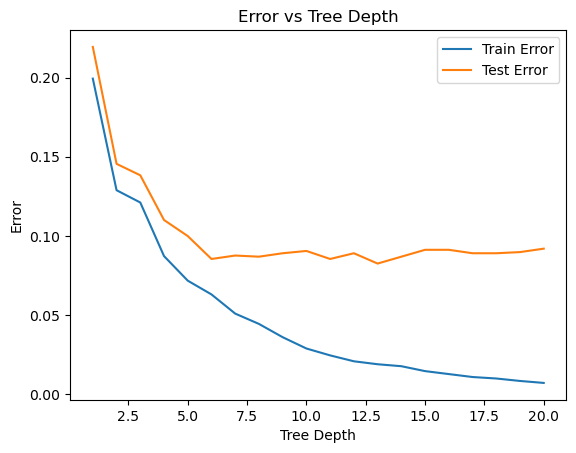

Best depth: 13


In [10]:
depths = range(1, 21)

train_errors = []
test_errors = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, y_train_pred))
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

# Plot
plt.figure()
plt.plot(depths, train_errors, label="Train Error")
plt.plot(depths, test_errors, label="Test Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")
plt.legend()
plt.show()

# Print best depth
best_depth = depths[test_errors.index(min(test_errors))]
print("Best depth:", best_depth)

The optimal depth is 13, as it minimizes the testing error in the plot. Shallower trees underfit the data, while deeper trees begin to overfit. Depth 13 provides the best balance between bias and variance.

#### Question 2.1

In [13]:
trees_list = [10, 50, 100, 500]

results = {}

for T in trees_list:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)

    # Train
    y_train_pred = rf.predict(X_train)
    y_train_prob = rf.predict_proba(X_train)[:, 1]

    # Test
    y_test_pred = rf.predict(X_test)
    y_test_prob = rf.predict_proba(X_test)[:, 1]

    train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

    results[T] = {"train": train_metrics, "test": test_metrics}

for T in trees_list:
    print(f"\n=== T = {T} ===")
    print("Train (Acc, F1, AUC):", results[T]["train"])
    print("Test  (Acc, F1, AUC):", results[T]["test"])


=== T = 10 ===
Train (Acc, F1, AUC): {'Error': 0.004658385093167738, 'Accuracy': 0.9953416149068323, 'F1 Score': 0.9938999593330622, 'AUC': 0.9999681921390542}
Test  (Acc, F1, AUC): {'Error': 0.05648081100651703, 'Accuracy': 0.943519188993483, 'F1 Score': 0.9304812834224598, 'AUC': 0.9796177259284168}

=== T = 50 ===
Train (Acc, F1, AUC): {'Error': 0.00031055900621113075, 'Accuracy': 0.9996894409937889, 'F1 Score': 0.9995956328346138, 'AUC': 0.9999993883103664}
Test  (Acc, F1, AUC): {'Error': 0.04344677769732075, 'Accuracy': 0.9565532223026793, 'F1 Score': 0.9469964664310954, 'AUC': 0.9883597609870922}

=== T = 100 ===
Train (Acc, F1, AUC): {'Error': 0.00031055900621113075, 'Accuracy': 0.9996894409937889, 'F1 Score': 0.9995956328346138, 'AUC': 0.9999993883103664}
Test  (Acc, F1, AUC): {'Error': 0.04344677769732075, 'Accuracy': 0.9565532223026793, 'F1 Score': 0.9469026548672567, 'AUC': 0.9879652862205437}

=== T = 500 ===
Train (Acc, F1, AUC): {'Error': 0.00031055900621113075, 'Accurac

As T increases from 10 to 50, the test accuracy, F1 score, and AUC improve. Beyond T = 50, the metrics stabalize, with almost no improvement and even a slight fluctuation at T = 500|. This indicates that increasing the number of trees reduces variance initially, but after a certain point, additional trees provide diminishing returns.

#### Question 2.2

Random Forest outperforms the single decision tree on the test set, achieving higher accuracy of 95.6% vs 91.9%, F1 score, and AUC. While the decision tree shows clear overfitting with a near perfect training performance but lower test performance, Random Forest reduces overfitting by averaging multiple trees. This results in better generalization and more stable predictions across different values of 𝑇. 

#### Question 2.3

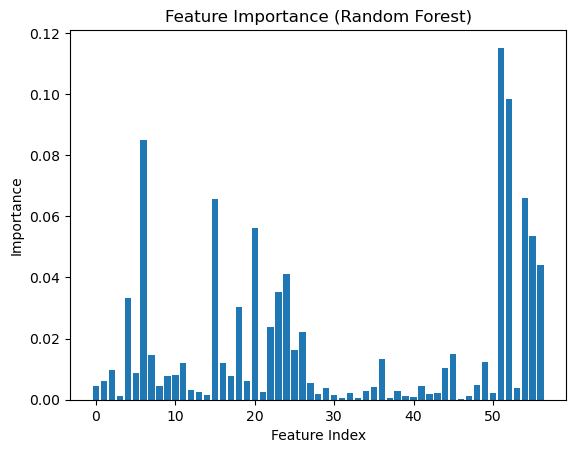


Top 10 Important Features:
Feature 51: 0.1151
Feature 52: 0.0984
Feature 6: 0.0848
Feature 54: 0.0659
Feature 15: 0.0655
Feature 20: 0.0560
Feature 55: 0.0536
Feature 56: 0.0442
Feature 24: 0.0410
Feature 23: 0.0353


In [18]:
# Train 
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

# Plot
plt.figure()
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

# Top 10 features
important_features = sorted(
    enumerate(importances), key=lambda x: x[1], reverse=True
)[:10]

print("\nTop 10 Important Features:")
for idx, val in important_features:
    print(f"Feature {idx}: {val:.4f}")

#### Question 3.1

In [20]:
from sklearn.tree import DecisionTreeClassifier

T_values = [10, 50, 100, 500]

for T in T_values:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  # weak learner (stump)
        n_estimators=T,
        random_state=42
    )
    
    ada.fit(X_train, y_train)

    # Train
    y_train_pred = ada.predict(X_train)
    y_train_prob = ada.predict_proba(X_train)[:, 1]

    # Test
    y_test_pred = ada.predict(X_test)
    y_test_prob = ada.predict_proba(X_test)[:, 1]

    train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

    print(f"\n=== AdaBoost T = {T} ===")
    print("Train:", train_metrics)
    print("Test :", test_metrics)


=== AdaBoost T = 10 ===
Train: {'Error': 0.07546583850931676, 'Accuracy': 0.9245341614906832, 'F1 Score': 0.9001233045622689, 'AUC': 0.9687349116557052}
Test : {'Error': 0.07965242577842147, 'Accuracy': 0.9203475742215785, 'F1 Score': 0.9017857142857143, 'AUC': 0.9672758391750089}

=== AdaBoost T = 50 ===
Train: {'Error': 0.05590062111801242, 'Accuracy': 0.9440993788819876, 'F1 Score': 0.926530612244898, 'AUC': 0.9893718926166614}
Test : {'Error': 0.06661839246922518, 'Accuracy': 0.9333816075307748, 'F1 Score': 0.9190140845070424, 'AUC': 0.9786045940143303}

=== AdaBoost T = 100 ===
Train: {'Error': 0.042857142857142816, 'Accuracy': 0.9571428571428572, 'F1 Score': 0.9440842787682334, 'AUC': 0.9936363888453911}
Test : {'Error': 0.05937726285300504, 'Accuracy': 0.940622737146995, 'F1 Score': 0.9285714285714286, 'AUC': 0.9812344257913207}

=== AdaBoost T = 500 ===
Train: {'Error': 0.009627329192546608, 'Accuracy': 0.9903726708074534, 'F1 Score': 0.987444309437019, 'AUC': 0.99960668356561

#### Question 3.2

In [22]:
T_values = [10, 50, 100, 500]

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)

    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        random_state=42
    )
    ada.fit(X_train, y_train)

    # RF test
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    # Ada test
    ada_pred = ada.predict(X_test)
    ada_prob = ada.predict_proba(X_test)[:, 1]

    rf_metrics = compute_metrics(y_test, rf_pred, rf_prob)
    ada_metrics = compute_metrics(y_test, ada_pred, ada_prob)

    print(f"\n=== T = {T} ===")
    print("Random Forest:", rf_metrics)
    print("AdaBoost     :", ada_metrics)


=== T = 10 ===
Random Forest: {'Error': 0.05648081100651703, 'Accuracy': 0.943519188993483, 'F1 Score': 0.9304812834224598, 'AUC': 0.9796177259284168}
AdaBoost     : {'Error': 0.07965242577842147, 'Accuracy': 0.9203475742215785, 'F1 Score': 0.9017857142857143, 'AUC': 0.9672758391750089}

=== T = 50 ===
Random Forest: {'Error': 0.04344677769732075, 'Accuracy': 0.9565532223026793, 'F1 Score': 0.9469964664310954, 'AUC': 0.9883597609870922}
AdaBoost     : {'Error': 0.06661839246922518, 'Accuracy': 0.9333816075307748, 'F1 Score': 0.9190140845070424, 'AUC': 0.9786045940143303}

=== T = 100 ===
Random Forest: {'Error': 0.04344677769732075, 'Accuracy': 0.9565532223026793, 'F1 Score': 0.9469026548672567, 'AUC': 0.9879652862205437}
AdaBoost     : {'Error': 0.05937726285300504, 'Accuracy': 0.940622737146995, 'F1 Score': 0.9285714285714286, 'AUC': 0.9812344257913207}

=== T = 500 ===
Random Forest: {'Error': 0.044895003620564755, 'Accuracy': 0.9551049963794352, 'F1 Score': 0.945326278659612, 'AUC

#### Question 3.3

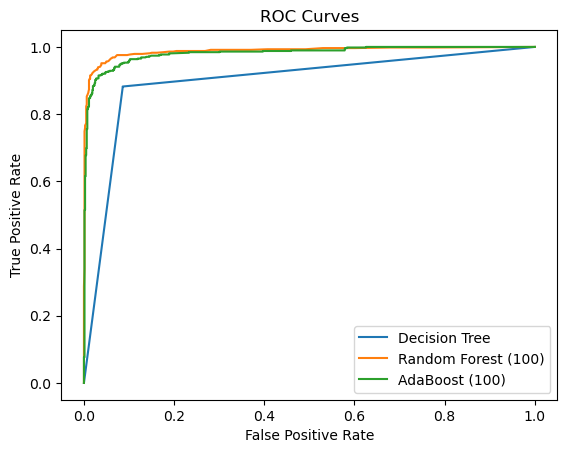

In [24]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_prob = dt.predict_proba(X_test)[:, 1]

# Random Forest (100)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

# AdaBoost (100)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train, y_train)
ada_prob = ada.predict_proba(X_test)[:, 1]

# ROC curves
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

# Plot
plt.figure()
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest (100)")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost (100)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

#### Question 4.1

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

file_path = "agaricus-lepiota.data"

columns = [
    "class","cap-shape","cap-surface","cap-color","bruises","odor",
    "gill-attachment","gill-spacing","gill-size","gill-color",
    "stalk-shape","stalk-root","stalk-surface-above-ring",
    "stalk-surface-below-ring","stalk-color-above-ring",
    "stalk-color-below-ring","veil-type","veil-color","ring-number",
    "ring-type","spore-print-color","population","habitat"
]

df = pd.read_csv(file_path, header=None, names=columns)

# Handle missing values
df.replace("?", np.nan, inplace=True)
df.fillna("missing", inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Split data
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Naive Bayes training
class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.cond_probs = {}

        n_samples = len(y)

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.cond_probs[c] = {}

            for col in X.columns:
                self.cond_probs[c][col] = {}
                values = np.unique(X[col])

                for v in values:
                    count = len(X_c[X_c[col] == v])
                    # Laplace smoothing
                    self.cond_probs[c][col][v] = (
                        (count + 1) / (len(X_c) + len(values))
                    )

nb = NaiveBayes()
nb.fit(X_train, y_train)
print("Class Priors:", nb.priors)

Class Priors: {0: 0.5199409158050221, 1: 0.48005908419497784}


#### Question 4.2

In [28]:
def predict_proba(nb, X):
    results = []

    for _, row in X.iterrows():
        class_probs = {}

        for c in nb.classes:
            prob = nb.priors[c]

            for col in X.columns:
                val = row[col]
                prob *= nb.cond_probs[c][col].get(val, 1e-6)

            class_probs[c] = prob

        # Normalize probabilities
        total = sum(class_probs.values())
        for c in class_probs:
            class_probs[c] /= total

        results.append(class_probs)

    return results

probs = predict_proba(nb, X_test)

# Separate probabilities
prob_edible = [p[0] for p in probs]
prob_poisonous = [p[1] for p in probs]
print(prob_edible[:5], prob_poisonous[:5])

[0.999992814171691, 1.8710211587340353e-10, 8.971446190655131e-12, 0.9999999831229532, 1.7863595678562164e-10] [7.185828309009591e-06, 0.9999999998128979, 0.9999999999910285, 1.6877046805249296e-08, 0.999999999821364]


#### Question 4.3

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def predict(nb, X):
    preds = []

    for _, row in X.iterrows():
        class_probs = {}

        for c in nb.classes:
            prob = nb.priors[c]

            for col in X.columns:
                val = row[col]
                prob *= nb.cond_probs[c][col].get(val, 1e-6)

            class_probs[c] = prob

        preds.append(max(class_probs, key=class_probs.get))

    return preds

# Predictions
y_pred = predict(nb, X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Manual Naive Bayes Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Manual Naive Bayes Results:
Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945


#### Question 4.4

In [32]:
from sklearn.naive_bayes import CategoricalNB

# Train sklearn Naive Bayes
sk_nb = CategoricalNB()
sk_nb.fit(X_train, y_train)

# Predictions
y_pred_sk = sk_nb.predict(X_test)

# Metrics
accuracy_sk = accuracy_score(y_test, y_pred_sk)
precision_sk = precision_score(y_test, y_pred_sk)
recall_sk = recall_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk)

print("Sklearn Naive Bayes Results:")
print("Accuracy:", accuracy_sk)
print("Precision:", precision_sk)
print("Recall:", recall_sk)
print("F1 Score:", f1_sk)

Sklearn Naive Bayes Results:
Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945


The results from the manual Naive Bayes implementation and the sklearn implementation are identical across all evaluation metrics (accuracy, precision, recall, and F1 score). This indicates that both models behave the same on this dataset, confirming that the manual implementation is correct and consistent with the package implementation.
